# Task multi-label training

Trains a single multi-label model on the 4-class task dataset (3 target
species + `non_target`). Outputs are independent sigmoids — a clip can
fire more than one class at a time, which matches reality (multiple birds
can be present in the same window).

Only the float `.keras` model is saved here. Post-training quantization,
evaluation and all metrics/plots live in `results.ipynb` so PTQ knobs can
be re-explored without retraining.

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from pathlib import Path
import os

import pyrootutils

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)

## Parameters

In [13]:
# COLLECTION is the on-disk dataset folder name produced by
# dataset_build.ipynb — i.e. task_slug(TARGET_SPECIES, LAT, LON, RADIUS_KM).
COLLECTION = "task_s3_49_2_r50"
BUILD_MODEL = "leaf"  # one of: mel_cnn, mel_cnn_2, cnn1d, sincnet, leaf, transformer, squeezenet_mel, squeezenet_time
EPOCHS = 100
PATIENCE = 10
BATCH_SIZE = 16
SEED = 42
NON_TARGET_NAME = "non_target"

MODEL_PATH = ROOT / "models" / COLLECTION / f"{BUILD_MODEL}.keras"

## Load dataset catalog

Uses the same per-class cached waveform catalog that `scaling.py` builds. The
first run populates `.cache/<collection>/waveform_<hash>/` for each split; later
runs hit the cache directly.

In [14]:
import logging
import warnings

import numpy as np
import tensorflow as tf

tf.get_logger().setLevel("ERROR")
logging.getLogger("absl").setLevel("ERROR")
warnings.filterwarnings("ignore", message=".*AudioResample.*")

from building.scaling import (
    build_dataset_from_catalog,
    collect_predictions,
    compute_metrics,
    load_dataset_catalog,
    model_factory,
)
from building.models import input_repr_for

catalog = load_dataset_catalog(COLLECTION)

non_target_idx = catalog.class_names.index(NON_TARGET_NAME)
target_idxs = [i for i, n in enumerate(catalog.class_names) if n != NON_TARGET_NAME]
final_labels = [catalog.class_names[i] for i in target_idxs] + [NON_TARGET_NAME]
print(f"target_idxs={target_idxs}  non_target_idx={non_target_idx}")
print(f"final label order: {final_labels}")

target_idxs=[0, 1, 2]  non_target_idx=3
final label order: ['Emberiza_calandra', 'Hippolais_polyglotta', 'Regulus_ignicapilla', 'non_target']


In [15]:
import pandas as pd

counts = pd.DataFrame(
    [(e.name, e.train.count, e.val.count, e.test.count) for e in catalog.entries],
    columns=["class", "train", "val", "test"],
).set_index("class")
counts["total"] = counts.sum(axis=1)
counts.loc["TOTAL"] = counts.sum(axis=0)

(
    counts.style
    .background_gradient(cmap="Blues", subset=(counts.index[:-1], ["train", "val", "test"]))
    .format("{:,}")
    .set_caption(f"Sample counts per class × split  ({COLLECTION})")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "110%"), ("padding", "6px 0")]},
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])
)

,train,val,test,total
class,,,,
Emberiza_calandra,"5,600","1,200","1,200","8,000"
Hippolais_polyglotta,"5,431","1,163","1,165","7,759"
Regulus_ignicapilla,"5,600","1,200","1,200","8,000"
non_target,"17,912","3,835","3,847","25,594"
TOTAL,"34,543","7,398","7,412","49,353"


## Build train/val pipelines

`build_dataset_from_catalog` shuffles each class independently, repeats, and
mixes via `sample_from_datasets` so every training batch is class-balanced
regardless of class size. Validation uses the natural distribution. The test
split is built later in `results.ipynb` (alongside PTQ).

In [16]:
input_repr = input_repr_for(BUILD_MODEL)
rng = np.random.default_rng(SEED)

train_ds, meta = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="train", input_repr=input_repr, augment=True,
)
val_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="val", input_repr=input_repr, augment=False,
)
print(f"n_classes={meta.n_classes}  epoch_samples={meta.epoch_samples}")
print("class_weights:")
for lbl, w in meta.class_weights.items():
    print(f"  {final_labels[lbl]:<24s} {w:.3f}")

n_classes=4  epoch_samples=34543
class_weights:
  Emberiza_calandra        1.196
  Hippolais_polyglotta     1.233
  Regulus_ignicapilla      1.196
  non_target               0.374


## Build model and train

In [17]:
tf.keras.backend.clear_session()
model = model_factory(BUILD_MODEL)(meta.n_classes)
model.summary()

Model: "leaf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ audio (InputLayer)              │ (None, 48000, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gabor_conv (GaborConv1D)        │ (None, 3000, 32)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gauss_pool (GaussianPool1D)     │ (None, 750, 32)        │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pcen (PCEN)                     │ (None, 750, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pcen_bn (BatchNormalization)    │ (None, 750, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 750, 16)        │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 750, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 750, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 375, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 375, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 375, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 375, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 375, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 187, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,292 (24.58 KB)

 Trainable params: 6,004 (23.45 KB)

 Non-trainable params: 288 (1.12 KB)

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
        ),
    ],
)
print(f"Stopped after {len(history.history['loss'])} epochs")

Epoch 1/100
2159/2159 - 54s - 25ms/step - accuracy: 0.6812 - loss: 0.2447 - precision: 0.7436 - recall: 0.6065 - val_accuracy: 0.7474 - val_loss: 0.2171 - val_precision: 0.7949 - val_recall: 0.6971
Epoch 2/100
2159/2159 - 50s - 23ms/step - accuracy: 0.7833 - loss: 0.1613 - precision: 0.8196 - recall: 0.7358 - val_accuracy: 0.7242 - val_loss: 0.3368 - val_precision: 0.7355 - val_recall: 0.7138
Epoch 3/100
2159/2159 - 50s - 23ms/step - accuracy: 0.8275 - loss: 0.1305 - precision: 0.8619 - recall: 0.7900 - val_accuracy: 0.7099 - val_loss: 0.6885 - val_precision: 0.7025 - val_recall: 0.7278
Epoch 4/100
2159/2159 - 50s - 23ms/step - accuracy: 0.8465 - loss: 0.1198 - precision: 0.8758 - recall: 0.8104 - val_accuracy: 0.7267 - val_loss: 0.5012 - val_precision: 0.7569 - val_recall: 0.7155
Epoch 5/100
2159/2159 - 52s - 24ms/step - accuracy: 0.8553 - loss: 0.1120 - precision: 0.8832 - recall: 0.8225 - val_accuracy: 0.7697 - val_loss: 0.4006 - val_precision: 0.7389 - val_recall: 0.7897
Epoch 6/10

KeyboardInterrupt: 

## Training curves

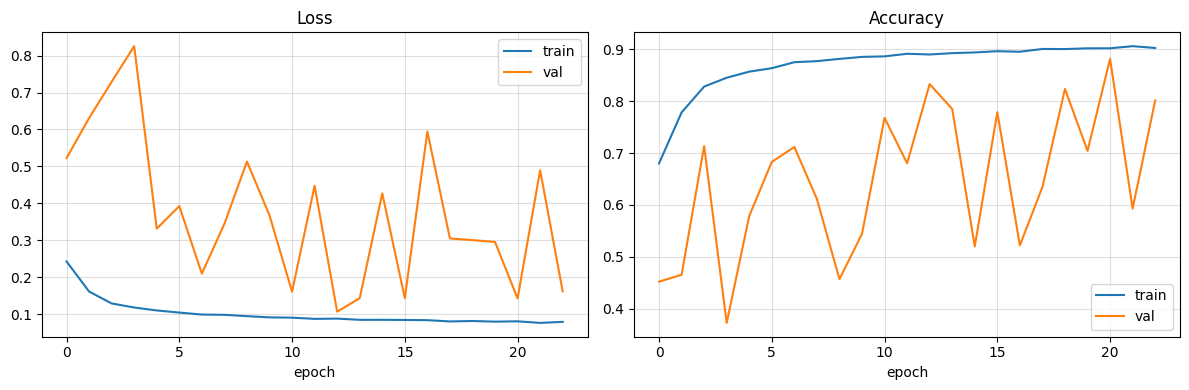

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.4)

acc_key = next(
    (k for k in ("accuracy", "categorical_accuracy") if k in history.history),
    None,
)
if acc_key is not None:
    axes[1].plot(history.history[acc_key], label="train")
    axes[1].plot(history.history[f"val_{acc_key}"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Save float model

Persists the float `.keras` model. PTQ + evaluation happen in `results.ipynb`
so you can re-quantize with different knobs without retraining.

In [ ]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
model.save(MODEL_PATH)
print(f"Saved float : {MODEL_PATH}")
print("\nRun PTQ and render results via building/geographic_task/results.ipynb.")

Saved float : /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/leaf.keras

Run PTQ and render results via building/geographic_task/results.ipynb.
